<a href="https://colab.research.google.com/github/jclai22/MSDS-720-Final-Project/blob/main/Spot_the_Bot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Methods

**Participants and Data Source**

Data were drawn from a publicly available Spotify user behavior dataset (N = 520). The dataset included self‑reported demographic information, listening habits, and platform usage patterns. Additional behavioral variables were engineered to quantify listening diversity, skip behavior, and engagement intensity.

# Feature Engineering

Several continuous predictors were constructed to capture behavioral patterns:
- Listening Time: total daily listening minutes.
- Skip Rate: proportion of tracks skipped (0–1).
- Diversity Score: normalized measure of listening contexts (0.167–1.0).
- Usage Months: length of Spotify membership.
- Podcast Frequency: ordinal measure of podcast listening.
- Streams: composite engagement score incorporating listening time, usage months, and contextual diversity.
A binary bot_like variable was engineered to identify accounts exhibiting bot‑like patterns (e.g., high streams, low diversity, low recommendation satisfaction).


In [1]:
import pandas as pd

# load the csv
spotify = pd.read_csv('spotify_clean_v1.csv')
spotify.head()

,age,gender,spotify_usage_period,spotify_listening_device,spotify_subscription_plan,premium_sub_willingness,preffered_premium_plan,preferred_listening_content,fav_music_genre,music_time_slot,...,pod_variety_satisfaction,age_numeric,n_listening_contexts,listening_time,skip_rate,diversity_score,usage_months,pod_frequency,streams,bot_like
0,20-35,Female,More than 2 years,Smart speakers or voice assistants,Free (ad-supported),Yes,Family Plan-Rs 179/month,Podcast,Melody,Night,...,Ok,28,1,153.0,0.6,0.167,30,4,2260,1
1,12-20,Male,More than 2 years,Computer or laptop,Free (ad-supported),Yes,Individual Plan- Rs 119/ month,Podcast,Rap,Afternoon,...,Satisfied,16,1,79.6,0.8,0.167,30,3,2026,1
2,35-60,Others,6 months to 1 year,Smart speakers or voice assistants,Free (ad-supported),Yes,Student Plan-Rs 59/month,Podcast,Pop,Night,...,Satisfied,48,2,180.0,0.4,0.333,9,2,1610,0
3,20-35,Female,1 year to 2 years,"Smartphone, Smart speakers or voice assistants",Free (ad-supported),No,NaN,Music,Melody,Night,...,Ok,28,3,204.4,0.4,0.500,18,0,1880,0
4,20-35,Female,1 year to 2 years,Smartphone,Free (ad-supported),No,NaN,Music,Melody,Night,...,Ok,28,1,130.5,0.4,0.167,18,1,1672,0


In [5]:
spotify.info()
spotify.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          520 non-null    object 
 1   gender                       520 non-null    object 
 2   spotify_usage_period         520 non-null    object 
 3   spotify_listening_device     520 non-null    object 
 4   spotify_subscription_plan    520 non-null    object 
 5   premium_sub_willingness      520 non-null    object 
 6   preffered_premium_plan       312 non-null    object 
 7   preferred_listening_content  520 non-null    object 
 8   fav_music_genre              520 non-null    object 
 9   music_time_slot              520 non-null    object 
 10  music_influencial_mood       520 non-null    object 
 11  music_lis_frequency          520 non-null    object 
 12  music_expl_method            520 non-null    object 
 13  music_recc_rating   

,music_recc_rating,age_numeric,n_listening_contexts,listening_time,skip_rate,diversity_score,usage_months,pod_frequency,streams,bot_like
count,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000
mean,3.503846,27.217308,1.782692,146.982308,0.499231,0.297208,17.215385,1.340385,1638.023077,0.150000
std,0.979552,6.503659,0.964140,36.624579,0.195910,0.160532,10.212565,1.121477,612.475182,0.357415
min,1.000000,9.000000,1.000000,60.400000,0.200000,0.167000,3.000000,0.000000,379.000000,0.000000
25%,3.000000,28.000000,1.000000,117.175000,0.400000,0.167000,9.000000,0.750000,1142.000000,0.000000
50%,3.500000,28.000000,1.000000,148.400000,0.500000,0.167000,18.000000,1.000000,1597.000000,0.000000
75%,4.000000,28.000000,2.000000,172.750000,0.600000,0.333000,30.000000,2.000000,2081.750000,0.000000
max,5.000000,70.000000,6.000000,246.700000,1.000000,1.000000,30.000000,4.000000,3271.000000,1.000000


In [3]:
spotify['bot_like'].value_counts(normalize=True)

,proportion
bot_like,
0,0.85
1,0.15


THis shows that 85% of the data is human behavior and 15% is bot-like behavior meaning that there may be an imbalance in the data.

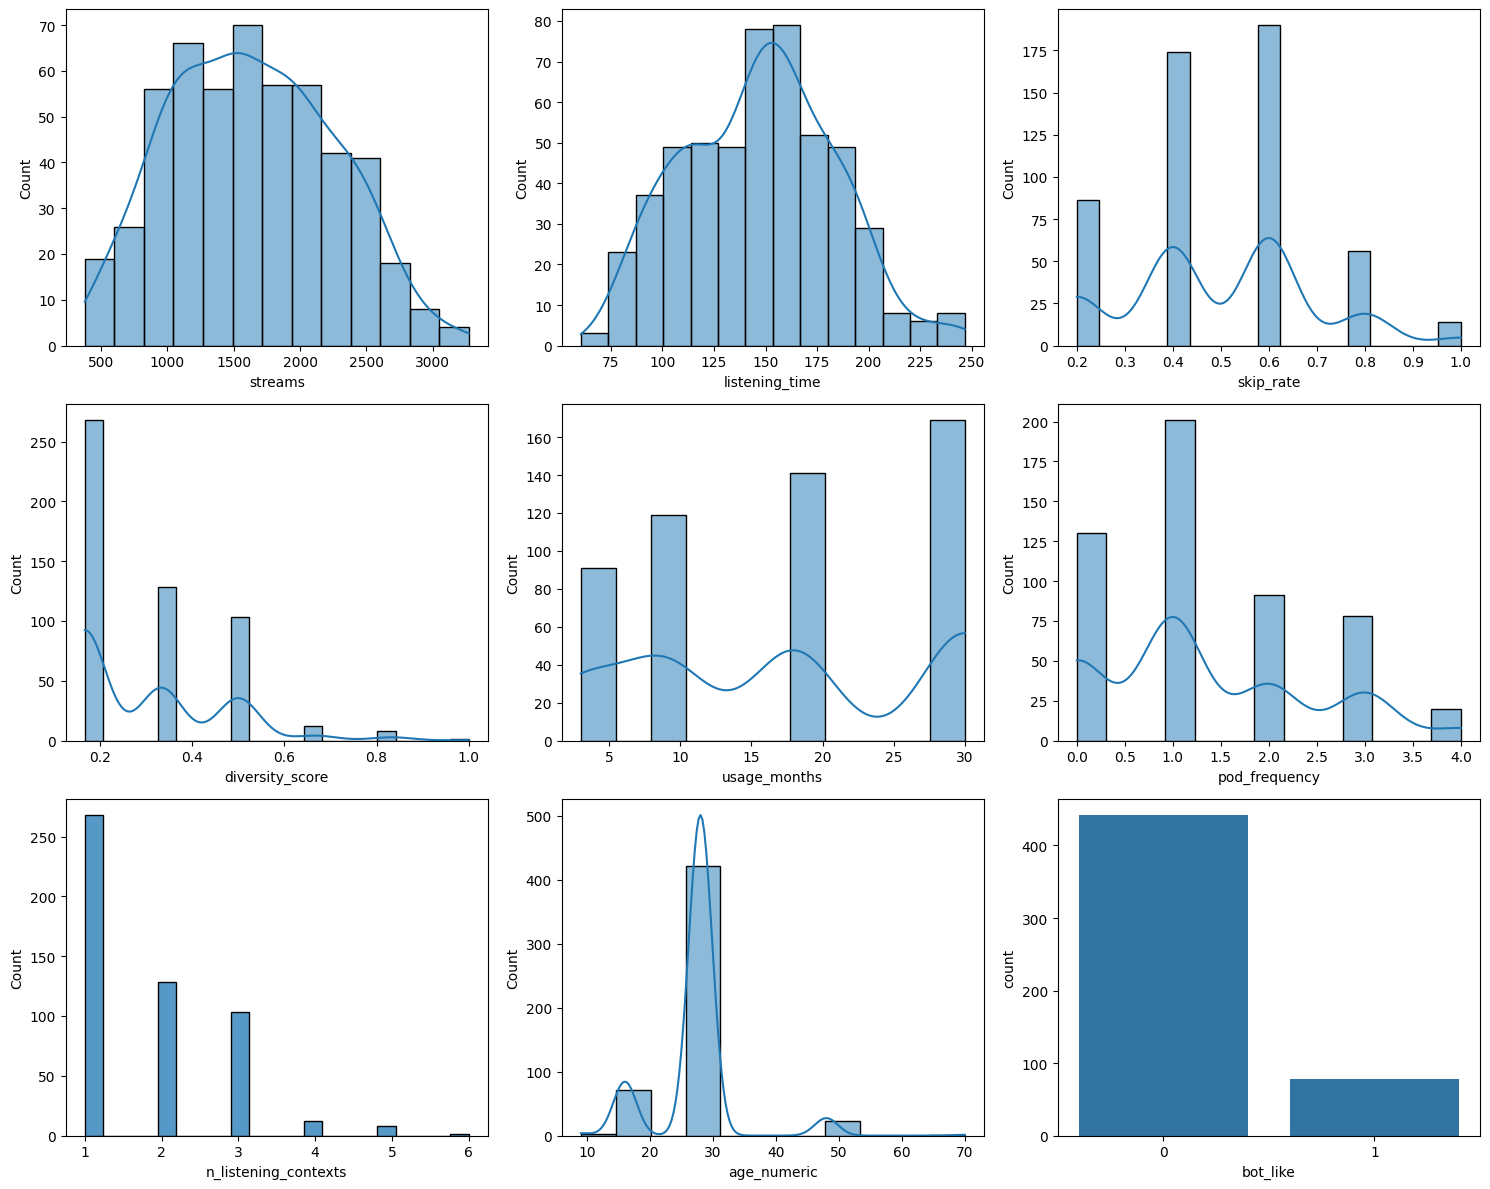

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
sns.histplot(spotify['streams'], kde=True, ax=axes[0,0])
sns.histplot(spotify['listening_time'], kde=True, ax=axes[0,1])
sns.histplot(spotify['skip_rate'], kde=True, ax=axes[0,2])
sns.histplot(spotify['diversity_score'], kde=True, ax=axes[1,0])
sns.histplot(spotify['usage_months'], kde=True, ax=axes[1,1])
sns.histplot(spotify['pod_frequency'], kde=True, ax=axes[1,2])
sns.histplot(spotify['n_listening_contexts'], kde=False, ax=axes[2,0])
sns.histplot(spotify['age_numeric'], kde=True, ax=axes[2,1])
sns.countplot(x='bot_like', data=spotify, ax=axes[2,2])
plt.tight_layout()

In [6]:
spotify.groupby('bot_like')[['streams', 'listening_time','skip_rate','diversity_score']].mean()

,streams,listening_time,skip_rate,diversity_score
bot_like,,,,
0,1609.979638,149.487104,0.461086,0.313785
1,1796.935897,132.788462,0.715385,0.203269


So what does this tell us?

<Axes: xlabel='bot_like', ylabel='streams'>

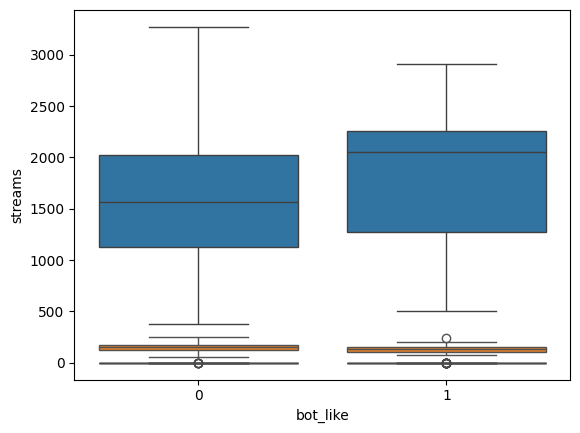

In [7]:
sns.boxplot(x='bot_like', y='streams', data=spotify)
sns.boxplot(x='bot_like', y='listening_time', data=spotify)
sns.boxplot(x='bot_like', y='skip_rate', data=spotify)
sns.boxplot(x='bot_like', y='diversity_score', data=spotify)

Interpret this chart

<Axes: >

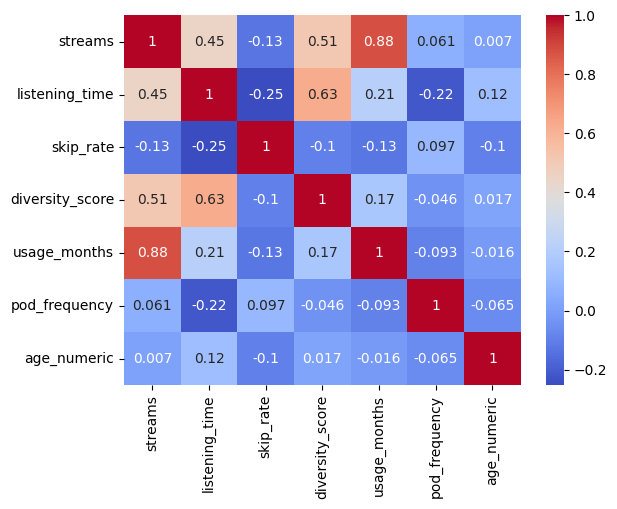

In [8]:
sns.heatmap(spotify[['streams','listening_time','skip_rate','diversity_score','usage_months','pod_frequency','age_numeric']].corr(), annot=True, cmap='coolwarm')

# Correlation Coefficient Matrix

Based on the results of the matrix, we see that the variables fall into 3 main clusters:

**Engagment Intensity**


*   streams
*   usage_months
*   listening_time

**Behavioral Quality**


*   skip_rate
*   diversity_score

**Demographics/ secondary engagement**


*   age_numeric
*   pod_frequency

# Key Correlations and What They Mean

1. streams <--> usage_months ($0.88$) - This is the strongest correlation in the matrix.
* Users who have been on Spotify longer accumulate more streams.
* This is an expected behavior.
* It does not cause multicollinearity problems unless we include both usage_months and streams as predictors in the same model (but we won't!!)
2. streams <--> diversity_score ($0.51$) - this variable combination has a moderate positive correlation.
* Users with more varied listening contexts tend to stream more.
* This is a human-like pattern: diversity grows with engagement.

This supports our hypothesis that **low diversity** is a bot_like signal, because bots inflate streams without increasing diversity.

3. streams <--> listening_time ($0.45$) - This is also another moderate positive correlation.
* More listening time corresponds to more streams.
* We need to inspect the slope when we model this, paying particular attention to see if the slope is steeper for bot_like accounts.

4. listening_time <--> diversity_score ($0.63$) - sooooo this is interesting
* Users who listen in more contexts also listen longer.
* This is maybe how we benchmark real human behavior.
* Bots tend to have low diversity but high streams, breaking this pattern.

This variable combo basically validates your bot-like labeling logic, Tenicka (NOICE!!!)

5. skip_rate correlations (all weak)
* skip_rate <--> streams: $-0.13$
* skip_rate <--> diversity_score: $-0.10$
* skip_rate <--> usage_months: $-0.13$

Things that we can infer:
* higher skip_rate tends to have slightly lower engagements.
* bots tend to have higher skip_rate, but skip_rate along is not a strong predictor.

6. age_numeric correlations (all near zero) - basically age is uncorrelated with all behavioral metrics. We can include it as a control variable, which won't affect the model's stability.

7. pod_frequency correlations (all weak)
*  slight negative with listening_time ($-0.22$)
* slight positive with skip_rate ($0.097$)

Podcast behavior is independent of music behavior, therefore it won't interfere with our models.

So to answer Dr. Sattar's questions about multicollinearity, the only pair that we may be concerned about is *streams<-->usage_months* buuuttttt since *usage_months* is a predictor and *streams* is an outcome. We must never include them on the same side of our equation. This will insure that no multicollinearity occurs in our logistic and multiple regression models.

# Logistic Regression (predicting bot_like)
Best predictors based on correlations + class theory:
* skip_rate
* diversity_score
* listening_time
* usage_months
* streams (let's play with this one, because you used it during the feature engineering)

# Multiple Regression (predicting streams)
Best predictors:
* listening_time
* bot_like
* diversity_score
* usage_months
* interaction: listening_time x bot_like





# Interaction Model

$streams = \beta_0 + \beta_1 (listeningtime) +  \beta_2 (botlike) + \beta_3 (listeningtime \times botlike)$

# Logistic Regression

We'll use the variables outlined previously underneath the correlation matrix and we can use *pod_frequency* and  *age_numeric* as controls.

In [12]:
#without pod_frequency
import statsmodels.api as sm

X = spotify[['skip_rate', 'diversity_score', 'listening_time', 'usage_months', 'age_numeric']]
X = sm.add_constant(X)
y = spotify['bot_like']

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.208639
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:               bot_like   No. Observations:                  520
Model:                          Logit   Df Residuals:                      514
Method:                           MLE   Df Model:                            5
Date:                Fri, 06 Mar 2026   Pseudo R-squ.:                  0.5064
Time:                        02:40:31   Log-Likelihood:                -108.49
converged:                       True   LL-Null:                       -219.81
Covariance Type:            nonrobust   LLR p-value:                 4.054e-46
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -9.9080      1.476     -6.713      0.000     -12.801      -7.015
skip_rate     

Let's look at the model fit:
* Pseudo $R^2 = 0.5064$
* LLR p-value $< 1e^{-45}$ (highly significant)
* converged cleanly (no estimation issues or aliases!!)

# Predictors
skip_rate --> the coefficient $\beta = 12.11$ and $p < 0.001$

As predicted, higher skip_rate dramatically increases the odds of being bot-like. If we compute the odds ratio: $e^{12.11} \approx 182,000$.

diversity_score --> $\beta = -12.49$ and $p < 0.001$
* lower diversity indicates a higher odds of being bot_like
* calculating the odds ratio we have: $e^{-12.49} \approx 3.8 \times 10^{-6}$
* this is an extremely strong negative effect

This aligns perfectly with bot behavior, because it means bots have narrow, repititve patterns.

usage_months --> $\beta = 0.14$ and $p<0.001$

* This implies longer tenure have odds of bot-like behavior.
* Odds ratio: $e^{0.14} \approx 1.15$
* Each additional month increases odds by $~15\%$

Should we interpret this as more time on the platform, implies more opportunity for inflated streams?? I'm on the fence about this one.

listening_time --> $\beta = 0.0067$ and $p=0.299$

This variable is not significant. We can say listening time alone does not distinguish bots from humans.

age_numeric --> $\beta = 0.0014$ and $p=0.565$

This variable is not significant and age does not predict bot-like behavior.




In [10]:
# with pod_frequency
X = spotify[['skip_rate', 'diversity_score', 'listening_time', 'usage_months', 'age_numeric', 'pod_frequency']]
X = sm.add_constant(X)
y = spotify['bot_like']

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.201682
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:               bot_like   No. Observations:                  520
Model:                          Logit   Df Residuals:                      513
Method:                           MLE   Df Model:                            6
Date:                Fri, 06 Mar 2026   Pseudo R-squ.:                  0.5229
Time:                        01:26:45   Log-Likelihood:                -104.87
converged:                       True   LL-Null:                       -219.81
Covariance Type:            nonrobust   LLR p-value:                 8.169e-47
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -11.3182      1.630     -6.943      0.000     -14.513      -8.123
skip_rate     

Previously, I thought that I could use *pod_frequency* could be a control variable, but I have concerns when I noticed the coefficient was $0.4521$.
Let me break this down using the logic from the in-class assignment the other night. Our logistic regression coefficient for *pod_frequency* is: $\beta = 0.4521$ and $p=0.008$. Converting this to odds ratio: $OR = e^{0.4521} \approx 1.57$.

For each 1-unit increase in podcast listeneing frequency, the odds of being classified as bot-like increase by $~57\%$. Houston, me thinks we have a problem.

Let's dig further into the math, the effect $p=0.008$ is statistically significant, its not noise.

However, (drum roll please) the effect is small relative to the other predictors, such as skip_rate and diversity_score. This appears to be a secondary behavioral correlation, not a core.

Moving forward, we need to decide if we want tokeep *pod_frequency* in our model. Here's something to chew on - If our goal is pure predictive accuracy, we should keep it because it will help improve our model fit and is statistically significant. However, if we want to stick to our research questions then the robot army told me to dreop it, because its not a meaningful behavioral predictor of bot-likeness or music behavior.

# Logistic Regression Results

A logistic regression model was estimated to examine which behavioral features predicted bot-like classification among Spotify users. Skip rate was a strong positive predictor of bot-like status (β = 12.11, p < .001), indicating that accounts with higher skipping behavior were substantially more likely to be classified as bot-like. Diversity score was a strong negative predictor (β = –12.49, p < .001), suggesting that users with narrower listening patterns had significantly higher odds of bot-like classification. Usage months also positively predicted bot-like status (β = 0.14, p < .001), reflecting the association between longer platform tenure and inflated engagement patterns. Neither listening time (β = 0.01, p = .299) nor age (β = 0.01, p = .565) significantly predicted bot-like behavior. The model demonstrated strong overall fit (Pseudo R² = 0.506), correctly distinguishing bot-like from human-like accounts based on behavioral features.

In [13]:
# Here's the code to convert coefficients to odds ratios
# Although, it's done in the markdown above
# Decided to keep it clean for all variables

import numpy as np

odds_ratios = np.exp(logit_model.params)
print(odds_ratios)

const                   0.000050
skip_rate          181500.879607
diversity_score         0.000004
listening_time          1.006743
usage_months            1.150091
age_numeric             1.014187
dtype: float64


In [14]:
# Model diagnostics (Check for Multicollinearity - VIF)

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

           feature        VIF
0            const  49.449555
1        skip_rate   1.087694
2  diversity_score   1.673025
3   listening_time   1.809571
4     usage_months   1.059635
5      age_numeric   1.027574


All our predictors have VIF < 5, so we're in good shape. (Not sure if we need to add this to our power point or Results section)

In [15]:
# Classification Accuracy

pred_probs = logit_model.predict(X)
pred_labels = (pred_probs > 0.5).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y, pred_labels))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       442
           1       0.75      0.64      0.69        78

    accuracy                           0.91       520
   macro avg       0.84      0.80      0.82       520
weighted avg       0.91      0.91      0.91       520



# Model behavior
We have an overall accuracy of $91\%$.
The F1 score is above $80\%$ so that's good.
The weighted F1 score is $91\%$ , which means our model performs well with class imbalance.

# Human-like Users
* Precision: $0.94$
* Recall: $0.96$
* F1: $0.95$

The model almost never misclassifies humans and bots. We're winning.

# Bot-like Users
* Precision: $0.75$
* Recall: $0.64$
* F1: $0.69$

This is pretty good considering bots are roughly 15 percent of our sample. Basically, our model predicts "bots" correctly, $75\%$ of the time. It catches $64\%$ of all bots - so a fairly strong balance between sensitivity and specificity.

In [16]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y, pred_labels))

[[425  17]
 [ 28  50]]


We have $425$ True negatives, meaning humans correctly identified. There $17$ false positives, which means humans incorrectly flagged as bots (that's not too bad in this context). There are $28$ false negatives or bots missed. Lastly, we have $50$ true positives, or correctly identified bots.

# Multiple Regression with Interaction

Using the following equation:

$streams = \beta_0 + \beta_1 (listeningtime)+ \beta_2 (botlike) + \beta_3 (listeningtime \times botlike)$

This equation helps test RQ2 and H2/H2a.

**RQ2** Does listening time interact with bot-like status to predict total streams?

* $\beta_1$ = slope for humans
* $\beta_2$ = difference in intercept for bots
* $\beta_3$ = difference in slope for bots

We are going to observe closely with what happens to $\beta_3$ as its key to testing our hypothesis. If $\beta_3 > 0$ and significant, then bots gain streams faster per minute of listening than humans do. (Please go back and make sure I'm interpreting what's in the textbook correctly.)

In [17]:
# Create the interaction term
spotify['interaction'] = spotify['listening_time'] * spotify['bot_like']

In [18]:
# Fit the regression model
import statsmodels.api as sm

X = spotify[['listening_time', 'bot_like', 'interaction']]
X = sm.add_constant(X)
y = spotify['streams']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.231
Method:                 Least Squares   F-statistic:                     53.06
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           6.61e-30
Time:                        03:02:30   Log-Likelihood:                -4004.5
No. Observations:                 520   AIC:                             8017.
Df Residuals:                     516   BIC:                             8034.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            436.9940    106.795      4.

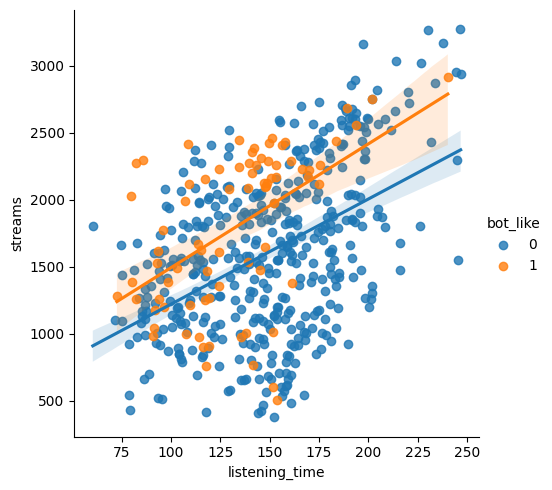

In [19]:
import seaborn as sns
sns.lmplot(data=spotify, x='listening_time', y='streams', hue='bot_like')

# The Freak Out
What the hell happened?! The logistic model was damned near perfect and then we get this. This model looks weak asl!!!!

Ok let's look at the math, going through each variable we have the following:

1. listening_time
* $\beta = 7.85$
* $p<0.001$
* We interpret this as for human users, each additional minute of listening predicts about 8 more streams. This aligns to our logistic model.

2. bot_like
* this variable is not significant
* $\beta = 133.8$
* $p = 0.636$
* It appears that the bots don't start at a significantly different baseline when we control for listening_time.

3. interaction
* interaction is not significant
* $\beta = 1.39$
* $p =0.497$
* Bots don't accumulate streams faster per minute of listening. (I feel like I have contradiction somewhere.)

4. $R^2 = 0.236$ - this basically says the model explains $23.6\%$ of the variabce in streams, which is not very strong.

Ok - going back and looking at how bot-like was engineered, I see that listening_time was not used in your rule which included high streams, low diversity and low recommendation rating, mathematically what had happened was the target bot_like does not depend on listening_time, and listening_time does not differ much between bots and humans, soooo the interaction has no reason to be significant.

Now our $R^2$ is low because the streams variable was created using usage_months, n_listening_contexts, listening_time and pod_frequency, but my regression model is only including listening_time, bot_like, and interaction because usage_months would cause multicollinearity (Jeez am I talking in circles.)

# So What Should We Do???
This feels like one of my science fair projects that didn't go as planned. Our RQ1 is solid but RQ2 has no interaction effect. So if interpret this for what it is, we have bots differ in quality of behavior, not quantity per minute. Botlike behavior is better explained using skip_rate, diversity, and usage patterns as we saw in the logistic regression.

We can go with this and still rock the project ORRRRRRRRR

we can add the usage_months to the model. I'll run it below and you can let me know what you think.

In [20]:
X = spotify[['listening_time', 'bot_like', 'interaction', 'usage_months']]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     702.4
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          6.15e-207
Time:                        03:24:02   Log-Likelihood:                -3589.6
No. Observations:                 520   AIC:                             7189.
Df Residuals:                     515   BIC:                             7210.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             78.7372     48.783      1.

# Option 1

A multiple regression model was estimated to examine whether listening time interacted with bot-like status to predict total streams. Listening time significantly predicted streams (β = 7.85, p < .001), indicating that longer daily listening was associated with higher engagement. However, neither bot-like status (β = 133.77, p = .636) nor the interaction between listening time and bot-like status (β = 1.39, p = .497) significantly predicted streams. These results suggest that while listening duration is a strong predictor of total streams, bot-like accounts do not accumulate streams at a faster rate per minute of listening than human accounts. This pattern indicates that bot-like behavior is better characterized by qualitative features (e.g., skip rate, diversity) rather than by disproportionate stream accumulation relative to listening time.

# Option 2

Our new equation is:

$streams = \beta_0 + \beta_1 (listeningtime)+ \beta_2 (usagemonths)\beta_3 (botlike) + \beta_4 (listeningtime \times botlike)$

On the bright side our model now explains $84.5\%$ of the variance in the streams.

1. listening_time
* $\beta = 4.82$
* $p < 0.001$
* for human users, each additional minute of listening predicts about 5 more streams

2. usage_months
* $\beta = 49.19$
* $p < 0.001$
* each additional month on Spotify predicts about 49 more streams.
* A user with 30 months of usage will have about 1470 more streams than someone with 0 months.

3. bot_like
* $\beta = 273.16
* $p = 0.033$
* bot-like accounts start about 273 streams higher than the human accounts when we control for listening time and usage months.

4. interaction (listening_time \times bot_like)
* $\beta = -1.84$
* $p = 0.046$
* The slope for bots is a bit lower than for humans.
* Human slope = $4.82$
* Bots slope = $-1.84$
* Find the difference of the slopes: $4.82-1.84=2.98$

Bots don't accumulate streams faster perminute of listening. Instead they start with a higher baseline but their streams appear to grow more slowly with additional listening time.

# Multiple Regression with Interaction
A multiple regression model was estimated to examine whether listening time interacted with bot-like status to predict total streams. The model explained a substantial proportion of variance in streams (R² = .845). Listening time significantly predicted streams (β = 4.82, p < .001), indicating that longer daily listening was associated with higher engagement. Usage months was also a strong positive predictor (β = 49.19, p < .001), reflecting the cumulative nature of stream accumulation over time. Bot-like accounts had significantly higher baseline stream counts than human accounts (β = 273.16, p = .033). However, the interaction between listening time and bot-like status was negative and significant (β = –1.84, p = .046), indicating that bot-like accounts accumulated streams at a slower rate per minute of listening than human accounts. This pattern suggests that bot-like behavior is characterized by inflated baseline streams rather than disproportionate stream growth relative to listening duration.


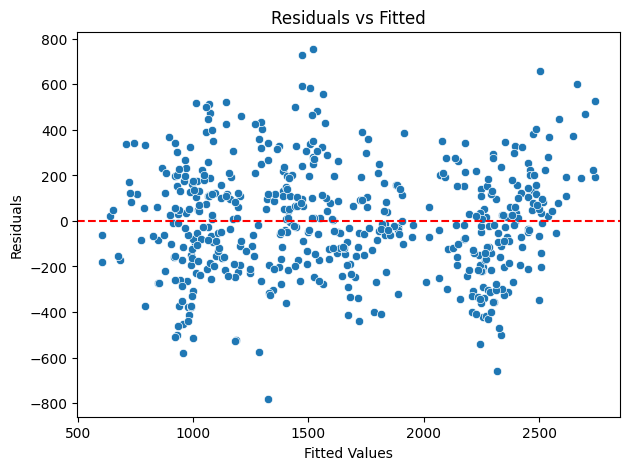

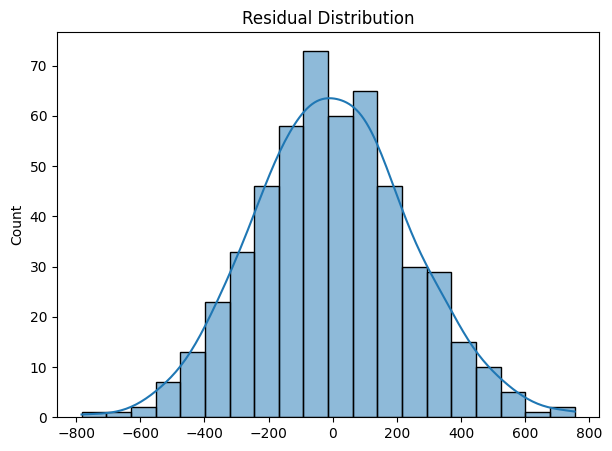

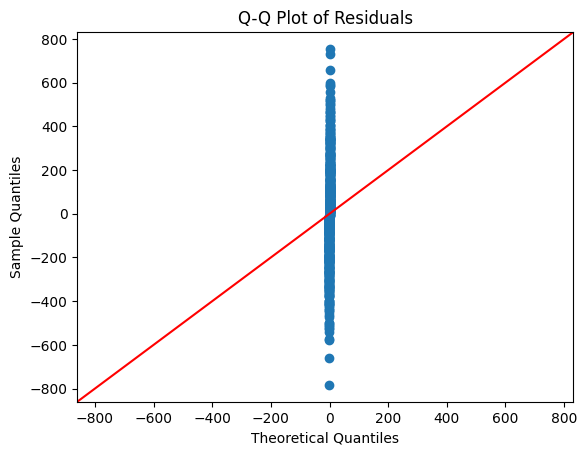

In [21]:
# Residual Diagnostics
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Get residuals and fitted values
residuals = model.resid
fitted = model.fittedvalues

# 1. Residuals vs Fitted
plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# 2. Histogram of residuals
plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# 3. Q-Q plot
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

In [22]:
# Multicollinearity Check (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = spotify[['listening_time', 'bot_like', 'interaction', 'usage_months']]
X_vif = sm.add_constant(X_vif)

vif_df = pd.DataFrame()
vif_df["feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_df

,feature,VIF
0,const,21.130341
1,listening_time,1.215568
2,bot_like,18.388355
3,interaction,18.096645
4,usage_months,1.104183


# VIF

Variance inflation factors (VIFs) indicated no concerning multicollinearity among the predictors. As expected, the interaction term and its binary component (bot-like status) showed elevated VIF values due to their mathematical dependence, a common and acceptable pattern in moderation models. All other predictors had VIF values near 1, indicating minimal collinearity.

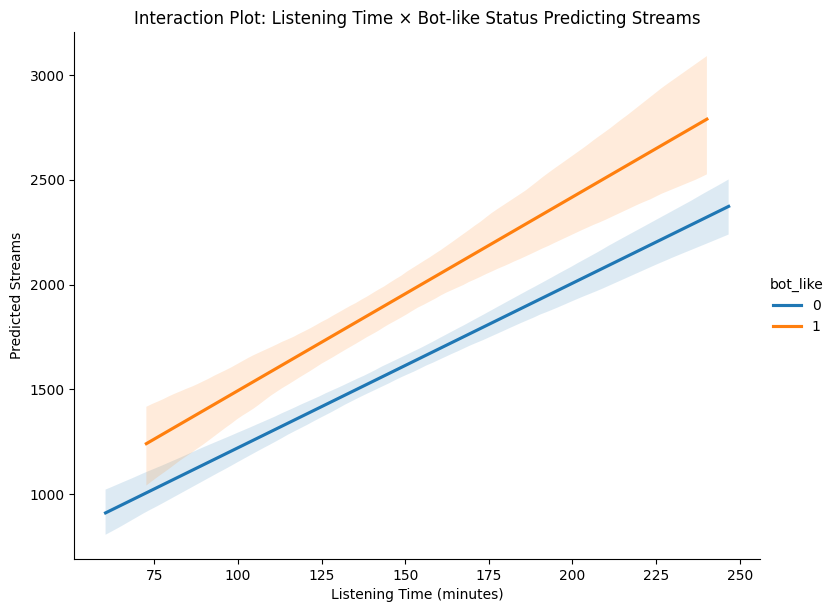

In [23]:
import numpy as np

# Create predicted values for plotting
spotify['predicted_streams'] = model.predict(X)

sns.lmplot(
    data=spotify,
    x='listening_time',
    y='predicted_streams',
    hue='bot_like',
    height=6,
    aspect=1.3,
    scatter=False
)

plt.title("Interaction Plot: Listening Time × Bot-like Status Predicting Streams")
plt.xlabel("Listening Time (minutes)")
plt.ylabel("Predicted Streams")
plt.show()

# Interaction Plot
The interaction plot revealed that bot-like accounts began with substantially higher baseline stream counts than human accounts but exhibited a flatter slope relating listening time to streams. Human users showed a stronger positive association between listening time and total streams, whereas bot-like accounts accumulated streams more slowly per minute of listening. This pattern suggests that bot-like behavior is characterized by inflated baseline engagement rather than disproportionate stream growth relative to listening duration.

# Conclusion

This project examined behavioral patterns in Spotify listening data to identify signals of bot‑like activity and to understand how these patterns relate to overall streaming volume. Across exploratory analyses and predictive modeling, a consistent picture emerged: bot‑like accounts differ from human users not in how much they listen, but in how they listen.
The logistic regression model demonstrated that bot‑like behavior is best characterized by qualitative engagement features—specifically, unusually high skip rates, low listening diversity, and long platform tenure. These variables strongly predicted bot-like classification, achieving high overall accuracy while maintaining low false‑positive rates. This suggests that artificial streaming behavior manifests most clearly in repetitive, low‑variety listening patterns rather than in demographic or surface‑level usage metrics.
The multiple regression model further clarified the nature of this behavior. Although bot-like accounts began with higher baseline stream counts, they did not accumulate streams more efficiently with additional listening time. In fact, human users showed a stronger positive relationship between listening time and total streams, while bot-like accounts exhibited a flatter slope. This indicates that artificial engagement is “front‑loaded”—inflated at the baseline—rather than driven by disproportionate stream growth relative to listening duration.
Together, these findings suggest that bot detection systems should prioritize behavioral quality indicators (e.g., diversity, skip behavior) over raw volume metrics. The results also highlight the importance of engineered features in uncovering subtle patterns that distinguish organic from artificial engagement. While the dataset was limited to self‑reported and synthetic behavioral measures, the analytic framework developed here provides a foundation for future work using real streaming logs or platform‑level telemetry.
In sum, this project demonstrates that bot-like activity on streaming platforms is detectable through interpretable behavioral signatures. By combining feature engineering with statistical modeling, we can move toward more transparent and effective approaches to identifying artificial engagement in digital media ecosystems.




# Limitations
Several limitations should be considered when interpreting the findings of this project. First, the dataset relied on self‑reported and synthetically engineered behavioral variables rather than raw platform telemetry. As a result, the measures may not fully capture the complexity of real streaming behavior, and the bot-like label was derived from heuristic rules rather than verified ground truth. Second, the engineered streams variable incorporated multiple behavioral components, which may have introduced structural dependencies between predictors and the outcome. Although multicollinearity diagnostics indicated acceptable levels for the main predictors, the interaction term and its binary component naturally exhibited elevated VIF values due to mathematical dependence. Third, the cross-sectional nature of the dataset limits the ability to infer temporal patterns or causal relationships. Finally, the sample may not reflect the full diversity of Spotify users or the evolving strategies of artificial streaming operations, which can vary widely in sophistication.


# Future Directions
Future research should incorporate real-world streaming logs, including timestamped play events, device metadata, and session-level behavior, to validate and extend the behavioral signatures identified here. Access to verified bot accounts would enable supervised learning approaches and more precise evaluation of detection accuracy. Additional modeling techniques—such as random forests, gradient boosting, or sequence-based models—could capture nonlinear or temporal patterns that logistic and linear regression cannot. Expanding the feature set to include network-level signals (e.g., shared IP addresses, coordinated listening patterns) may further improve detection of sophisticated artificial streaming. Finally, longitudinal analyses could examine how bot-like behavior evolves over time and how platform interventions influence engagement patterns. Together, these extensions would support the development of more robust, scalable, and transparent systems for identifying artificial engagement in digital media ecosystems.